In [231]:
## The task is to analyse the 25 data files, summarise the data contained therein, and present 
## them in a report that will illustrate which genes and mutations the company should focus their efforts on.

## Each mutation experiment file will contain the following data in a tab-separated format:

## Gene name, Wild-type gene DNA sequence including promoter and coding region, Mutant DNA gene sequence 
## including promoter and coding region, Normalised cell viability – expressed as a percentage for the original 
## and mutant gene in 3 replicates, Normalised mRNA expression level measured by qRT-PCR for the original and mutant gene 
## in 3 replicates, Normalised protein expression level measured by a protein array for the original and mutant gene in 3 replicates.

## The analysis will complete the following tasks:

## Aggregate data in all files into a single data object in Python

## Using the data provided, identify the top 5 genes and mutations to prioritise validation experiments.

## Demonstrate that you have considered the type of mutation (substitution, insertion, deletion), 
## effect of the mutations on cell viability, promoter and coding sequences, 
## as well as how the protein and mRNA expression levels differ between wild-type and mutants.

## Plot the data to support your choice of the 5 genes. You can include up to 3 individual figures (a multi-panel graph counts as 1 figure), 
## one of which should match the example graph provided (note the exact data points and variables need not be the same).

In [232]:
import os
import numpy as np
import pandas as pd
import re
import glob

In [233]:
## This cell will import the folder of text files into python, read them, and enter them into a data frame

folder_path = "C:/Users/kathr/OneDrive - University of Aberdeen/BT5511 Report 2/Text Files"
## sets the folder path used for the code

if not os.path.exists(folder_path):
    raise FileNotFoundError(f"Folder not found: {folder_path}")
## if the folder path does not exisat, inform user

txt_files = [f for f in os.listdir(folder_path) if f.endswith(".txt")]

if not txt_files:
    raise ValueError(f"No .txt files found in: {folder_path}")
## confirms the presence of txt files in the folder

dataframe = []
for filename in txt_files:
    file_path = os.path.join(folder_path, filename)
    try:  
        df = pd.read_csv(file_path, sep="\t")
        if df.empty:
            print(f"Warning: {filename} is empty, skipping.")
            ## tells user if there are empty files
            continue
        dataframe.append(df)
    except Exception as e:
        print(f"Warning: could not read {filename} — {e}")
        ## skips txt files that cannot be read instead of crashing

combined_data = pd.concat(dataframe, ignore_index=True, sort=False)
combined_data

,Gene,WildType.Sequence,Mutant.Sequence,mRNA.Expression.WT.Rep1,mRNA.Expression.WT.Rep2,mRNA.Expression.WT.Rep3,mRNA.Expression.Mut.Rep1,mRNA.Expression.Mut.Rep2,mRNA.Expression.Mut.Rep3,Protein.Expression.WT.Rep1,...,Protein.Expression.WT.Rep3,Protein.Expression.Mut.Rep1,Protein.Expression.Mut.Rep2,Protein.Expression.Mut.Rep3,CellViability.WT.Rep1,CellViability.WT.Rep2,CellViability.WT.Rep3,CellViability.Mut.Rep1,CellViability.Mut.Rep2,CellViability.Mut.Rep3
0,Ah3,TGCCCGTCGTCAGAGGGTGGACGGTTACTATCAACGTCCGCTTCCA...,TGCCCGTCGTCAGAGGGTGGACGGTTACTATCAACGTCCGCTTCCA...,3.183135e+08,2.617708e+01,16.735333,3.183135e+08,2.776962e+01,17.761754,11685.000000,...,37123.000000,11693.000000,26726.000000,37133.000000,0.261116,0.726898,0.633374,0.338555,0.750318,0.710077
1,Alli8,TTTACCAGAATCTATAACAGTATATGGCAAAATTCTCCCGCGTACT...,TTTACCAGAATCTATAACAGTATATGGCAAAATTCTCCCGCGTACT...,6.389135e+01,5.165643e+00,13.914518,6.275914e+01,5.012645e+00,13.013207,14317.000000,...,42445.000000,14334.000000,4914.000000,42448.000000,0.062666,0.090101,0.256835,0.074965,0.163613,0.220555
2,Anap7c1,GGGCGCATAGTAGGCAAGACACCTATTGCTAAAAAACGTCCTGGAC...,GGGCGCATAGTAGGCAAGACACCTATTGCTAAAAAACGTCCTGGAC...,1.629126e+00,2.097780e+01,7.266207,-3.674294e+00,-1.094399e+02,-5.597223,25803.000000,...,4047.000000,8711.000000,21503.000000,0.000000,0.528095,0.765748,0.273578,0.000000,0.000000,0.000000
3,App1l8,ATCTTATCGTACACTATTAATAAACTAGCGCTGATTCGAGTCGCTC...,ATCTTATCGTACACTATTAATAAACTAGCGCTGATTCGAGTCGCTC...,3.619328e+00,7.207154e+00,1.347365,3.898224e+00,6.585581e+00,0.413255,44784.000000,...,3517.000000,44785.000000,32607.000000,3530.000000,0.412541,0.059328,0.476712,0.184925,0.017589,0.460078
4,Avon4,TGAATCTAAGATTAAGTGGATATCGCCTTGACTTCTTTATCCATCC...,TGAATCTAAGATTAAGTGGATATCGCCTTGACTTCTTTATCCATCC...,1.398400e+00,1.745494e+00,4.394474,2.973012e+00,2.412630e+00,6.489425,29811.000000,...,45335.000000,54659.000000,55693.000000,55698.000000,0.829231,0.301918,0.795280,5.874721,6.243796,5.455045
5,Cairn3a2,GCACTATGGAACAAATCTCCGTAGGATAGCCAGAGTAAATCGGCCT...,GCACTATGGAACAAATCTCCGTAGGATAGCCAGAGTAAATCGGCCT...,2.529018e+01,2.711265e+00,48.099042,2.539605e+01,2.666513e+00,49.186680,25992.000000,...,31383.000000,26001.000000,27949.000000,31399.000000,0.633514,0.956889,0.518404,0.664322,0.970643,0.692276
6,Cairn6,GATTGCTAGTGGTAGTGGTGGCCCGGGTCGCCGTCCGCCACTCTTT...,GATTGCTAGTGGTAGTGGTGGCCCGGGTCGCCGTCCGCCACTCTTT...,2.084163e+01,3.676616e+01,5213.843993,2.274574e+01,3.577278e+01,5213.722502,48979.000000,...,27149.000000,48992.000000,33458.000000,27163.000000,0.925855,0.799526,0.801135,0.946808,0.806410,0.835041
7,Clach6,AAATGACATCCTCCGGGGAACGATGCAGGCCCAGTAAGCCAATACT...,AAATGACATCCTCCGGGGAACGATGCAGGCCCAGTAAGCCAATACT...,1.985791e+01,3.451715e+00,2.631587,1.783861e+01,3.045175e+00,3.017050,48988.000000,...,7210.000000,48994.000000,4939.000000,7221.000000,0.902357,0.554833,0.911485,0.884963,0.605348,1.001523
8,Dsgt9a1,ATAATCGCTGGTGTACTTCAAGTTACGACTTGAGTACGCATATCCA...,ATAATCGCTGGTGTACTTCAAGTTACGACTTGAGTACGCATATCCA...,9.898111e+00,2.371426e+00,101.458408,2.041802e+01,3.124716e+00,101.491889,25570.000000,...,10606.000000,41200.000000,42018.000000,25348.000000,0.637916,0.149896,0.124796,0.000000,0.000000,0.000000
9,Ever6b6,AAGTTATTCTACGGGCCCTCTATTGAATAGATAACCCAGGGGCGTG...,AAGTTATTCTACGGGCCCTCTATTGAATAGATAACCCAGGGGCGTG...,3.167661e+00,3.178356e+06,3.828825,2.268305e+00,3.178356e+06,2.285579,10686.000000,...,48037.000000,10695.000000,639.000000,48051.000000,0.108788,0.568027,0.022040,0.286469,0.673888,0.136360


In [234]:
## This cell will identify type of mutation present in each mutant sequence when compared to refernce sequence

VALID_BASES = set("ATCG")
## sets the valid DNA bases and A, C, T, and G

def validate_inputs(df, col2, col3):
    for col in [col2, col3]:
        if col not in df.columns:
            raise KeyError(f"Column '{col}' not found. Available columns: {df.columns.tolist()}")
    ## this validates that the columns set by the code exist in the data frame
    
    if df.empty:
        raise ValueError("DataFrame is empty.")
    ## this confirms that the data frame is not empty

def validate_sequence(seq, row_index, col_name):
    ## validates that the sequences only contain valid DNA bases
    
    invalid = set(seq) - VALID_BASES
    if invalid:
        raise ValueError(f"Row {row_index}, column '{col_name}' contains invalid bases: {invalid}")

def compare_dna_sequences(df, col2, col3):

    df.columns = df.columns.str.strip()
    ## get rid of whitespace in the columns

    results = []
    skipped_rows = []

    for index, row in df.iterrows():

        if pd.isna(row[col2]) or pd.isna(row[col3]):
            print(f"Warning: Row {index} contains missing sequence(s), skipping.")
            skipped_rows.append(index)
            continue
            ## tells the user if there are missing sequences in any of the columns

        seq1 = str(row[col2]).strip().upper()
        seq2 = str(row[col3]).strip().upper()
        ## strips any white space around the sequence and confirms every character is uppercase

        if len(seq1) == 0 or len(seq2) == 0:
            print(f"Warning: Row {index} contains empty sequence(s), skipping.")
            skipped_rows.append(index)
            continue
            ## another checkpoint to tell the user if there is a missing sequence

        try:
            validate_sequence(seq1, index, col2)
            validate_sequence(seq2, index, col3)
        except ValueError as e:
            print(f"Warning: {e}, skipping.")
            skipped_rows.append(index)
            continue
        ## validate the sequences again

        len1 = len(seq1)
        len2 = len(seq2)
        len_diff = len1 - len2
        ## calculate the difference in length between wildtype and mutation

        ## determine deletion or insertion
        if len_diff > 0:
            mutation_type = "Deletion"
            mutation_size = len_diff
            ## wildtype is longer so there is a deletion in mutated seq

            mutation_start = None
            for i, (base1, base2) in enumerate(zip(seq1, seq2)):
                if base1 != base2:
                    mutation_start = i + 1
                    break

            if mutation_start is None:
                mutation_start = len2 + 1

            affected_bases = seq1[mutation_start - 1: mutation_start - 1 + mutation_size]
            mutation_label = "Deleted bases"

            if mutation_size % 3 == 0:
                frameshift = "No — in-frame deletion"
                codon_effect = f"Deletion of {mutation_size} base(s) removes {mutation_size // 3} complete codon(s)"
                ## deletion removes at least one entire codon
            else:
                frameshift = "Yes — frameshift mutation"
                codon_effect = f"Deletion of {mutation_size} base(s) shifts reading frame by {mutation_size % 3} position(s)"
                ## deletion causes a frameshift

        elif len_diff < 0:
            mutation_type = "Insertion"
            mutation_size = abs(len_diff)
            ## mutated sequence is longer than wt

            mutation_start = None
            for i, (base1, base2) in enumerate(zip(seq1, seq2)):
                if base1 != base2:
                    mutation_start = i + 1
                    break

            if mutation_start is None:
                mutation_start = len1 + 1

            affected_bases = seq2[mutation_start - 1: mutation_start - 1 + mutation_size]
            mutation_label = "Inserted bases"

            if mutation_size % 3 == 0:
                frameshift = "No — in-frame insertion"
                codon_effect = f"Insertion of {mutation_size} base(s) adds {mutation_size // 3} complete codon(s)"
                ## insertion removes at least one entire codon
            else:
                frameshift = "Yes — frameshift mutation"
                codon_effect = f"Insertion of {mutation_size} base(s) shifts reading frame by {mutation_size % 3} position(s)"
                ## insertion causes frameshift 

        else:
            mutation_type = "Substitution"
            mutation_size = 0
            mutation_start = None
            affected_bases = None
            mutation_label = "Affected bases"
            frameshift = "No — same length, substitutions only"
            codon_effect = "No change in reading frame"

        ## position by position comparison
        max_len = max(len1, len2)
        seq1_padded = seq1.ljust(max_len, "-")
        seq2_padded = seq2.ljust(max_len, "-")

        mismatches = []
        diff_marker = []
        for i, (base1, base2) in enumerate(zip(seq1_padded, seq2_padded)):
            if base1 != base2:
                mismatches.append(f"pos {i+1}: {base1}->{base2}")
                diff_marker.append("^")
            else:
                diff_marker.append(".")

        alignment = "".join(diff_marker)
        mismatch_count = len(mismatches)
        percent_identity = round(((max_len - mismatch_count) / max_len) * 100, 2)

        results.append({
            "row_index":        index,
            "Gene":             row.get("Gene"),
            col2:               seq1,
            col3:               seq2,
            "alignment":        alignment,
            "mismatches":       ", ".join(mismatches) if mismatches else "None",
            "mismatch_count":   mismatch_count,
            "percent_identity": f"{percent_identity}%",
            "mutation_type":    mutation_type,
            "mutation_size":    mutation_size,
            "mutation_start":   mutation_start,
            mutation_label:     affected_bases,
            "frameshift":       frameshift,
            "codon_effect":     codon_effect
        })

        print(f"\n--- Row {index} ---")
        print(f"  Wildtype Sequence: {seq1}")
        print(f"  Mutated Sequence:     {seq2}")
        print(f"  Alignment: {alignment}")
        print(f"  Mismatches: {', '.join(mismatches) if mismatches else 'None'}")
        print(f"  Percent Identity: {percent_identity}%")
        print(f"  Mutation Type: {mutation_type}")
        if mutation_size > 0:
            print(f"  Mutation Size: {mutation_size} base(s)")
            print(f"  Mutation Start Position: {mutation_start}")
            print(f"  {mutation_label}: {affected_bases}")
        print(f"  Frameshift: {frameshift}")
        print(f"  Codon Effect: {codon_effect}")

    ## final summary
    if not results:
        raise ValueError("No valid rows were processed. Check your data for missing or invalid sequences.")
    
    print(f"\n=== Summary ===")
    print(f"  Rows processed:  {len(results)}")
    print(f"  Rows skipped:    {len(skipped_rows)}")
    if skipped_rows:
        print(f"  Skipped row indices: {skipped_rows}")

    return pd.DataFrame(results)

mutation_df = compare_dna_sequences(combined_data, "WildType.Sequence", "Mutant.Sequence")
print(mutation_df)


--- Row 0 ---
  Wildtype Sequence: TGCCCGTCGTCAGAGGGTGGACGGTTACTATCAACGTCCGCTTCCAAGCAGTCGGGCTTCAGGAACACCGTAGGCTTCTTTTGCCGCAGTTGGGCTCTACAACGGCGCAGAAAATGTACGGTCATAAACGCTGCACCTATAACCAACATCGTCACTAACCCTTTTGCGGGTCGTAGATTAAAAACGCTGACGGCAGTACGGCGTCTCTAGACGCCCGGGGGCAAATAAACATGGTCGATCAATGACGCCGTCAATCAACGGCAATAAAGTAGTTGGCCAGGTGCGAGTCACATCGGTGTCGAGTGTTCTTCCTCTCGCGTCCCGATGCGCAGCACGACTTCAAAGGTATTGGTTCCGTCATGCAACGTCGGATATCGAGTCACACTGTATTACCAAATTCTACTTTACCAGAGATATATAAGATGGAATACGCTATTTGTCACATAGTGTCCGATAACGTTGAAGTTAGATACATGCCGTACTGTCCCGTTTTTAAAGCCTGTCTTTGCGAGTGATCCAGTTGGTGCCGATAGTCATATTTCGCCCACAGAATCCCTTTACTGCACCGTCAGACAGTGAAATAGCAGGCGAAGCTAGGGTCCATTTTTTTTCGTATGCGTCGGGTACGCCGGAGGACGCGCAAGCTGCTTTTAGTCGAGGTCAACTTATGTCACGCGTGCTTCGTCTGCATTCCAGGATTAACTTCTGCACATACACAGAAAGCAAGAATGCCAAACGCATCCTTCCTTACCGGCTAGTGAGCCTACGCTTTCGCTGCTCTGACCTACTTCCTGGCGTTATGAGGGCTCCTGGCTCCTGCGACGGCGATGCCGTGTGGTACCAATCAAACTGCGGGTAGGTTCGAGGTTCGCATCAGACTAACCTCCGTTCCCACACGGGTTATTACACGAATAACGGCGACTCCATGGTCGCTCAACCCCCTTACAAGATTTAAATAAATGAA

In [235]:
## This cell will identify effect on promoter between wild-type and mutant

## define the TATA box promoter
tata_re = re.compile("TATA[A|T]A[A|T]")

## set valid bases and A, T, C, and G
VALID_BASES = set("ATCG")

## set TATA box length as 7 bases long
TATA_BOX_LENGTH = 7

## validate sequence contains appropriate bases
def validate_sequence(seq, row_index, col_name):
    invalid = set(seq) - VALID_BASES
    if invalid:
        raise ValueError(f"Row {row_index}, column '{col_name}' contains invalid characters: {invalid}")

## confirm sequence is long enough to contain a TATA box
def check_sequence_length(seq, row_index, col_name):
    if len(seq) < TATA_BOX_LENGTH:
        print(f"Warning: Row {row_index}, column '{col_name}' is shorter than {TATA_BOX_LENGTH} bases — too short to contain a TATA box, skipping.")
        return False
    return True

## confirm if there are multiple overlapping promoters
def check_overlapping_matches(seq, row_index, col_name):
    positions = [m.start() + 1 for m in tata_re.finditer(seq)]
    if len(positions) > 1:
        print(f"Warning: Row {row_index}, column '{col_name}' contains {len(positions)} TATA box matches at positions {positions} — multiple promoters detected.")

## check length differences between sequences
def check_length_difference(seq1, seq2, row_index, length_threshold=50):
    diff = abs(len(seq1) - len(seq2))
    if diff > length_threshold:
        print(f"Warning: Row {row_index} sequences differ in length by {diff} bases which may indicate a data entry error.")
        
## search the WT and mut sequences for the TATA box and compare
def check_promoter_sequence(df, col2, col3):
    """
    Args:
        df (pd.DataFrame): The DataFrame to search
        col1 (str): Name of the first sequence column (e.g. wildtype)
        col2 (str): Name of the second sequence column (e.g. mutant)

    Returns:
        pd.DataFrame: DataFrame with promoter detection results for every row
    """

    ## validate the input from each column
    for col in [col2, col3]:
        if col not in df.columns:
            raise KeyError(f"Column '{col}' not found. Available columns: {df.columns.tolist()}")

    if df.empty:
        raise ValueError("DataFrame is empty.")

    ## strip the whitespace from column names
    df.columns = df.columns.str.strip()

    results = []
    skipped_rows = []

    for index, row in df.iterrows():

        ## alert the user of skipping a row with a missing sequence
        if pd.isna(row[col2]) or pd.isna(row[col3]):
            print(f"Warning: Row {index} contains missing sequence(s), skipping.")
            skipped_rows.append(index)
            continue

        seq1 = str(row[col2]).strip().upper()
        seq2 = str(row[col3]).strip().upper()

        ## alert the user if either of the sequences is empty
        if len(seq1) == 0 or len(seq2) == 0:
            print(f"Warning: Row {index} contains empty sequence(s), skipping.")
            skipped_rows.append(index)
            continue

        ## search each sequence for a TATA box
        matches1 = tata_re.findall(seq1)
        matches2 = tata_re.findall(seq2)

        ## find the matching positions between WT and mut
        positions1 = [m.start() + 1 for m in tata_re.finditer(seq1)]  # 1-based position
        positions2 = [m.start() + 1 for m in tata_re.finditer(seq2)]  # 1-based position

        ## determine promoter status for WT and mut
        found1 = len(matches1) > 0
        found2 = len(matches2) > 0

        ## dompare promoter status between WT and mut
        if found1 and found2:
            comparison = "Promoter present in both sequences"
            interpretation = "Mutation has not disrupted the promoter"
        elif found1 and not found2:
            comparison = "Promoter lost in mutant sequence"
            interpretation = "Mutation may have disrupted the promoter — reduced transcription likely"
        elif not found1 and found2:
            comparison = "Promoter gained in mutant sequence"
            interpretation = "Mutation may have created a new promoter — altered transcription likely"
        else:
            comparison = "Promoter absent in both sequences"
            interpretation = "Neither sequence contains a detectable TATA box promoter"

        ## check if match positions have shifted
        if found1 and found2:
            if positions1 == positions2:
                position_change = "Promoter position unchanged"
            else:
                position_change = f"Promoter position shifted: {col2} at {positions1} vs {col3} at {positions2}"
        else:
            position_change = "N/A"

        results.append({
            "row_index":                    index,
            col2:                           seq1,
            col3:                           seq2,
            f"{col2}_promoter_found":       found1,
            f"{col2}_promoter_matches":     matches1 if matches1 else "None",
            f"{col2}_promoter_positions":   positions1 if positions1 else "None",
            f"{col3}_promoter_found":       found2,
            f"{col3}_promoter_matches":     matches2 if matches2 else "None",
            f"{col3}_promoter_positions":   positions2 if positions2 else "None",
            "comparison":                   comparison,
            "position_change":              position_change,
            "interpretation":               interpretation
        })

        ## print row summaries
        print(f"\n--- Row {index} ---")
        print(f"  {col2}: {seq1}")
        print(f"  {col3}: {seq2}")
        print(f"  {col2} promoter found:     {found1}")
        if found1:
            print(f"  {col2} matches:           {matches1}")
            print(f"  {col2} positions:         {positions1}")
        print(f"  {col3} promoter found:     {found2}")
        if found2:
            print(f"  {col3} matches:           {matches2}")
            print(f"  {col3} positions:         {positions2}")
        print(f"  Comparison:              {comparison}")
        print(f"  Position Change:         {position_change}")
        print(f"  Interpretation:          {interpretation}")

    ## final summary
    if not results:
        raise ValueError("No valid rows were processed. Check your data for missing or invalid sequences.")

    print(f"\n=== Summary ===")
    print(f"  Rows processed:                      {len(results)}")
    print(f"  Rows skipped:                        {len(skipped_rows)}")
    print(f"  Promoter present in both:            {sum(1 for r in results if r['comparison'] == 'Promoter present in both sequences')}")
    print(f"  Promoter lost in mutant:             {sum(1 for r in results if r['comparison'] == 'Promoter lost in mutant sequence')}")
    print(f"  Promoter gained in mutant:           {sum(1 for r in results if r['comparison'] == 'Promoter gained in mutant sequence')}")
    print(f"  Promoter absent in both:             {sum(1 for r in results if r['comparison'] == 'Promoter absent in both sequences')}")
    if skipped_rows:
        print(f"  Skipped row indices:                 {skipped_rows}")

    return pd.DataFrame(results)


## define columns
promoter_df = check_promoter_sequence(combined_data, "WildType.Sequence", "Mutant.Sequence")
print(promoter_df)


--- Row 0 ---
  WildType.Sequence: TGCCCGTCGTCAGAGGGTGGACGGTTACTATCAACGTCCGCTTCCAAGCAGTCGGGCTTCAGGAACACCGTAGGCTTCTTTTGCCGCAGTTGGGCTCTACAACGGCGCAGAAAATGTACGGTCATAAACGCTGCACCTATAACCAACATCGTCACTAACCCTTTTGCGGGTCGTAGATTAAAAACGCTGACGGCAGTACGGCGTCTCTAGACGCCCGGGGGCAAATAAACATGGTCGATCAATGACGCCGTCAATCAACGGCAATAAAGTAGTTGGCCAGGTGCGAGTCACATCGGTGTCGAGTGTTCTTCCTCTCGCGTCCCGATGCGCAGCACGACTTCAAAGGTATTGGTTCCGTCATGCAACGTCGGATATCGAGTCACACTGTATTACCAAATTCTACTTTACCAGAGATATATAAGATGGAATACGCTATTTGTCACATAGTGTCCGATAACGTTGAAGTTAGATACATGCCGTACTGTCCCGTTTTTAAAGCCTGTCTTTGCGAGTGATCCAGTTGGTGCCGATAGTCATATTTCGCCCACAGAATCCCTTTACTGCACCGTCAGACAGTGAAATAGCAGGCGAAGCTAGGGTCCATTTTTTTTCGTATGCGTCGGGTACGCCGGAGGACGCGCAAGCTGCTTTTAGTCGAGGTCAACTTATGTCACGCGTGCTTCGTCTGCATTCCAGGATTAACTTCTGCACATACACAGAAAGCAAGAATGCCAAACGCATCCTTCCTTACCGGCTAGTGAGCCTACGCTTTCGCTGCTCTGACCTACTTCCTGGCGTTATGAGGGCTCCTGGCTCCTGCGACGGCGATGCCGTGTGGTACCAATCAAACTGCGGGTAGGTTCGAGGTTCGCATCAGACTAACCTCCGTTCCCACACGGGTTATTACACGAATAACGGCGACTCCATGGTCGCTCAACCCCCTTACAAGATTTAAATAAATGAA

In [236]:
## This cell will anayse mRNA expression levels

## checks to see if any of the results will significantly skew the averages in the data
def check_outliers(values, row_index, group_name):
    if len(values) < 3:
        return
    q1, q3 = np.percentile(values, [25, 75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = [v for v in values if v < lower or v > upper]
    if outliers:
        print(f"Warning: Row {row_index} {group_name} contains potential outliers: {outliers}")

## calculates coefficient of variance to see if average is reliable
def check_variance(values, row_index, group_name, cv_threshold=1.0):
    mean = np.mean(values)
    if mean != 0:
        cv = np.std(values) / mean
        if cv > cv_threshold:
            print(f"Warning: Row {row_index} {group_name} has high variance (CV={round(cv, 3)}), results may be unreliable.")

## compares average mRNA expression levels between WT and mutant
def compare_mrna_expression(df, wt_cols, mut_cols, threshold=0.0, cv_threshold=0.2):
    """
    Args:
        df (pd.DataFrame): The DataFrame to compare
        mrna_wt_cols (list): List of 3 column names holding wildtype expression levels
        mrna_mut_cols (list): List of 3 column names holding mutated expression levels
        threshold (float): Minimum difference to flag as meaningful (default 0.0)
        cv_threshold (float): Coefficient of variation threshold for variance warning (default 0.2)

    Returns:
        pd.DataFrame: DataFrame with expression comparison details for every row
    """

    ## validate inputs to ensure all columns are accounted for
    if len(mrna_wt_cols) != 3 or len(mrna_mut_cols) != 3:
        raise ValueError("mrna_wt_cols and mrna_mut_cols must each contain exactly 3 column names.")

    ## check for duplicate column names in WT and mut groups
    if len(mrna_wt_cols) != len(set(mrna_wt_cols)):
        raise ValueError("mrna_wt_cols contains duplicate column names.")
    if len(mrna_mut_cols) != len(set(mrna_mut_cols)):
        raise ValueError("mrna_mut_cols contains duplicate column names.")

    ## check for overlap between groups
    overlap = set(mrna_wt_cols) & set(mrna_mut_cols)
    if overlap:
        raise ValueError(f"The following columns appear in both mrna_wt_cols and mrna_mut_cols: {overlap}")

    ## check all columns exist
    for col in mrna_wt_cols + mrna_mut_cols:
        if col not in df.columns:
            raise KeyError(f"Column '{col}' not found. Available columns: {df.columns.tolist()}")

    ## check columns contain numerical data
    for col in mrna_wt_cols + mrna_mut_cols:
        if not pd.api.types.is_numeric_dtype(df[col]):
            raise TypeError(f"Column '{col}' is not numeric. Please check your data.")

    ## check for negative mRNA expression values
    for col in mrna_wt_cols + mrna_mut_cols:
        if (df[col] < 0).any():
            print(f"Warning: Column '{col}' contains negative values which are not valid mRNA expression levels.")

    ## alert user if dataframe is empty
    if df.empty:
        raise ValueError("DataFrame is empty.")

    results = []
    skipped_rows = []

    for index, row in df.iterrows():

        ## get the WT values
        mrna_wt_values = []
        skip = False
        for col in mrna_wt_cols:
            val = row[col]
            if pd.isna(val):
                print(f"Warning: Row {index}, column '{col}' is missing, skipping row.")
                skipped_rows.append(index)
                skip = True
                break
            if not isinstance(val, (int, float)):
                print(f"Warning: Row {index}, column '{col}' is not numeric (got {type(val).__name__}), skipping row.")
                skipped_rows.append(index)
                skip = True
                break
            mrna_wt_values.append(float(val))

        if skip:
            continue

        ## get the mut values
        mrna_mut_values = []
        for col in mrna_mut_cols:
            val = row[col]
            if pd.isna(val):
                print(f"Warning: Row {index}, column '{col}' is missing, skipping row.")
                skipped_rows.append(index)
                skip = True
                break
            if not isinstance(val, (int, float)):
                print(f"Warning: Row {index}, column '{col}' is not numeric (got {type(val).__name__}), skipping row.")
                skipped_rows.append(index)
                skip = True
                break
            mrna_mut_values.append(float(val))

        if skip:
            continue

        ## check for outliers and high variance in WT and mut
        check_outliers(mrna_wt_values, index, "wildtype")
        check_outliers(mrna_mut_values, index, "mutant")
        check_variance(mrna_wt_values, index, "wildtype", cv_threshold)
        check_variance(mrna_mut_values, index, "mutant", cv_threshold)

        ## calculate averages of WT and mut
        mrna_wt_avg  = round(np.mean(mrna_wt_values), 4)
        mrna_mut_avg = round(np.mean(mrna_mut_values), 4)

        ## calculate difference and fold change for WT and mut
        difference     = round(mrna_mut_avg - mrna_wt_avg, 4)
        abs_difference = round(abs(difference), 4)

        if mrna_wt_avg != 0:
            fold_change    = round(mrna_mut_avg / mrna_wt_avg, 4)
            percent_change = round(((mrna_mut_avg - mrna_wt_avg) / mrna_wt_avg) * 100, 2)
        else:
            fold_change    = None
            percent_change = None
            print(f"Warning: Row {index} wildtype average is 0, fold change and percent change cannot be calculated.")

        ## determine if mRNA is upregulated or downregulated
        if difference > threshold:
            direction = "Upregulated in mutant"
        elif difference < -threshold:
            direction = "Downregulated in mutant"
        else:
            direction = "No meaningful difference"

        flagged = abs_difference > threshold

        results.append({
            "row_index":        index,
            "mrna_wt_values":        mrna_wt_values,
            "mrna_mut_values":       mrna_mut_values,
            "mrna_wt_average":       mrna_wt_avg,
            "mrna_mut_average":      mrna_mut_avg,
            "difference":       difference,
            "abs_difference":   abs_difference,
            "fold_change":      fold_change,
            "percent_change":   f"{percent_change}%" if percent_change is not None else "N/A",
            "direction":        direction,
            "flagged":          flagged
        })

        ## print row summaries
        print(f"\n--- Row {index} ---")
        print(f"  Wildtype values:   {mrna_wt_values}  →  Average: {mrna_wt_avg}")
        print(f"  Mutant values:     {mrna_mut_values}  →  Average: {mrna_mut_avg}")
        print(f"  Difference:        {difference}")
        print(f"  Fold Change:       {fold_change if fold_change is not None else 'N/A'}")
        print(f"  Percent Change:    {percent_change}%" if percent_change is not None else "  Percent Change:    N/A")
        print(f"  Direction:         {direction}")
        print(f"  Flagged:           {flagged}")

    ## final summary of data
    if not results:
        raise ValueError("No valid rows were processed. Check your data for missing or invalid values.")

    print(f"\n=== Summary ===")
    print(f"  Rows processed:          {len(results)}")
    print(f"  Rows skipped:            {len(skipped_rows)}")
    print(f"  Upregulated rows:        {sum(1 for r in results if r['direction'] == 'Upregulated in mutant')}")
    print(f"  Downregulated rows:      {sum(1 for r in results if r['direction'] == 'Downregulated in mutant')}")
    print(f"  No difference rows:      {sum(1 for r in results if r['direction'] == 'No meaningful difference')}")
    if skipped_rows:
        print(f"  Skipped row indices:     {skipped_rows}")

    return pd.DataFrame(results)


## set columns used
mrna_wt_cols  = ["mRNA.Expression.WT.Rep1", "mRNA.Expression.WT.Rep2", "mRNA.Expression.WT.Rep3"]
mrna_mut_cols = ["mRNA.Expression.Mut.Rep1", "mRNA.Expression.Mut.Rep2", "mRNA.Expression.Mut.Rep3"]

mrna_df = compare_mrna_expression(combined_data, mrna_wt_cols, mrna_mut_cols, threshold=1.0, cv_threshold=1.0)
print(mrna_df)


--- Row 0 ---
  Wildtype values:   [318313458.3416689, 26.17708058467153, 16.735332930495876]  →  Average: 106104500.418
  Mutant values:     [318313458.97207165, 27.76962121213539, 17.76175352804138]  →  Average: 106104501.5011
  Difference:        1.0831
  Fold Change:       1.0
  Percent Change:    0.0%
  Direction:         Upregulated in mutant
  Flagged:           True

--- Row 1 ---
  Wildtype values:   [63.89135378798004, 5.16564264421089, 13.914517713117272]  →  Average: 27.6572
  Mutant values:     [62.75913639958782, 5.0126452989692005, 13.01320700953497]  →  Average: 26.9283
  Difference:        -0.7289
  Fold Change:       0.9736
  Percent Change:    -2.64%
  Direction:         No meaningful difference
  Flagged:           False

--- Row 2 ---
  Wildtype values:   [1.6291256891247263, 20.977797974717323, 7.2662070181366385]  →  Average: 9.9577
  Mutant values:     [-3.6742942831503775, -109.43991405508838, -5.597223011862599]  →  Average: -39.5705
  Difference:        -49.

In [171]:
## This cell will identify protein expression levels between wild-type and mutant

## checks to see if any of the results will significantly skew the averages in the data
def check_outliers(values, row_index, group_name):
    if len(values) < 3:
        return
    q1, q3 = np.percentile(values, [25, 75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = [v for v in values if v < lower or v > upper]
    if outliers:
        print(f"Warning: Row {row_index} {group_name} contains potential outliers: {outliers}")

## calculates coefficient of variance to see if average is reliable
def check_variance(values, row_index, group_name, cv_threshold=1.0):
    mean = np.mean(values)
    if mean != 0:
        cv = np.std(values) / mean
        if cv > cv_threshold:
            print(f"Warning: Row {row_index} {group_name} has high variance (CV={round(cv, 3)}), results may be unreliable.")

## compares average mRNA expression levels between WT and mutant
def compare_protein_expression(df, protein_wt_cols, protein_mut_cols, threshold=1.0, cv_threshold=1.0):
    """
    Args:
        df (pd.DataFrame): The DataFrame to compare
        protein_wt_cols (list): List of 3 column names holding wildtype protein expression levels
        protein_mut_cols (list): List of 3 column names holding mutated protein expression levels
        threshold (float): Minimum difference to flag as meaningful (default 0.0)
        cv_threshold (float): Coefficient of variation threshold for variance warning (default 0.2)

    Returns:
        pd.DataFrame: DataFrame with protein expression comparison details for every row
    """

    ## validate inputs to ensure all columns are accounted for
    if len(protein_wt_cols) != 3 or len(protein_mut_cols) != 3:
        raise ValueError("protein_wt_cols and protein_mut_cols must each contain exactly 3 column names.")

    ## check for duplicate column names in WT and mut groups
    if len(protein_wt_cols) != len(set(protein_wt_cols)):
        raise ValueError("protein_wt_cols contains duplicate column names.")
    if len(protein_mut_cols) != len(set(protein_mut_cols)):
        raise ValueError("protein_mut_cols contains duplicate column names.")

    ## check for overlap between groups
    overlap = set(protein_wt_cols) & set(protein_mut_cols)
    if overlap:
        raise ValueError(f"The following columns appear in both protein_wt_cols and protein_mut_cols: {overlap}")

    ## check all columns exist
    for col in protein_wt_cols + protein_mut_cols:
        if col not in df.columns:
            raise KeyError(f"Column '{col}' not found. Available columns: {df.columns.tolist()}")

    ## check columns contain numerical data
    for col in protein_wt_cols + protein_mut_cols:
        if not pd.api.types.is_numeric_dtype(df[col]):
            raise TypeError(f"Column '{col}' is not numeric. Please check your data.")

    ## check for negative protein expression values
    for col in protein_wt_cols + protein_mut_cols:
        if (df[col] < 0).any():
            print(f"Warning: Column '{col}' contains negative values which are not valid protein expression levels.")

    ## alert user if dataframe is empty
    if df.empty:
        raise ValueError("DataFrame is empty.")

    results = []
    skipped_rows = []

    for index, row in df.iterrows():

        ## get the WT values
        protein_wt_values = []
        skip = False
        for col in protein_wt_cols:
            val = row[col]
            if pd.isna(val):
                print(f"Warning: Row {index}, column '{col}' is missing, skipping row.")
                skipped_rows.append(index)
                skip = True
                break
            if not isinstance(val, (int, float)):
                print(f"Warning: Row {index}, column '{col}' is not numeric (got {type(val).__name__}), skipping row.")
                skipped_rows.append(index)
                skip = True
                break
            protein_wt_values.append(float(val))

        if skip:
            continue

        ## get the mut values
        protein_mut_values = []
        for col in protein_mut_cols:
            val = row[col]
            if pd.isna(val):
                print(f"Warning: Row {index}, column '{col}' is missing, skipping row.")
                skipped_rows.append(index)
                skip = True
                break
            if not isinstance(val, (int, float)):
                print(f"Warning: Row {index}, column '{col}' is not numeric (got {type(val).__name__}), skipping row.")
                skipped_rows.append(index)
                skip = True
                break
            protein_mut_values.append(float(val))

        if skip:
            continue

        ## check for outliers and high variance in WT and mut
        check_outliers(protein_wt_values, index, "wildtype protein")
        check_outliers(protein_mut_values, index, "mutant protein")
        check_variance(protein_wt_values, index, "wildtype protein", cv_threshold)
        check_variance(protein_mut_values, index, "mutant protein", cv_threshold)

        ## calculate averages of WT and mut
        protein_wt_avg  = round(np.mean(protein_wt_values), 4)
        protein_mut_avg = round(np.mean(protein_mut_values), 4)

        ## calculate difference, fold change, and percent change for WT and mut
        difference     = round(protein_mut_avg - protein_wt_avg, 4)
        abs_difference = round(abs(difference), 4)

        if protein_wt_avg != 0:
            fold_change    = round(protein_mut_avg / protein_wt_avg, 4)
            percent_change = round(((protein_mut_avg - protein_wt_avg) / protein_wt_avg) * 100, 2)
        else:
            fold_change    = None
            percent_change = None
            print(f"Warning: Row {index} wildtype protein average is 0, fold change and percent change cannot be calculated.")

        ## determine if protein is upregulated or downregulated
        if difference > threshold:
            direction = "Upregulated in mutant"
        elif difference < -threshold:
            direction = "Downregulated in mutant"
        else:
            direction = "No meaningful difference"

        ## normalised ratio of protein expression (mutant relative to wildtype)
        if protein_wt_avg != 0:
            normalised_ratio = round(protein_mut_avg / protein_wt_avg, 4)
        else:
            normalised_ratio = None

        flagged = abs_difference > threshold

        results.append({
            "row_index":                index,
            "wt_protein_values":        protein_wt_values,
            "mut_protein_values":       protein_mut_values,
            "wt_protein_average":       protein_wt_avg,
            "mut_protein_average":      protein_mut_avg,
            "difference":               difference,
            "abs_difference":           abs_difference,
            "fold_change":              fold_change,
            "percent_change":           f"{percent_change}%" if percent_change is not None else "N/A",
            "normalised_ratio":         normalised_ratio,
            "direction":                direction,
            "flagged":                  flagged
        })

        ## print row summaries
        print(f"\n--- Row {index} ---")
        print(f"  Wildtype protein values:   {protein_wt_values}  →  Average: {protein_wt_avg}")
        print(f"  Mutant protein values:     {protein_mut_values}  →  Average: {protein_mut_avg}")
        print(f"  Difference:                {difference}")
        print(f"  Fold Change:               {fold_change if fold_change is not None else 'N/A'}")
        print(f"  Percent Change:            {percent_change}%" if percent_change is not None else "  Percent Change:    N/A")
        print(f"  Normalised Ratio:          {normalised_ratio if normalised_ratio is not None else 'N/A'}")
        print(f"  Direction:                 {direction}")
        print(f"  Flagged:                   {flagged}")

    ## final summary of data
    if not results:
        raise ValueError("No valid rows were processed. Check your data for missing or invalid values.")

    print(f"\n=== Summary ===")
    print(f"  Rows processed:              {len(results)}")
    print(f"  Rows skipped:                {len(skipped_rows)}")
    print(f"  Upregulated rows:            {sum(1 for r in results if r['direction'] == 'Upregulated in mutant')}")
    print(f"  Downregulated rows:          {sum(1 for r in results if r['direction'] == 'Downregulated in mutant')}")
    print(f"  No difference rows:          {sum(1 for r in results if r['direction'] == 'No meaningful difference')}")
    if skipped_rows:
        print(f"  Skipped row indices:         {skipped_rows}")

    return pd.DataFrame(results)


## set columns used
protein_wt_cols  = ["Protein.Expression.WT.Rep1", "Protein.Expression.WT.Rep2", "Protein.Expression.WT.Rep3"]
protein_mut_cols = ["Protein.Expression.Mut.Rep1", "Protein.Expression.Mut.Rep2", "Protein.Expression.Mut.Rep3"]

protein_df = compare_protein_expression(combined_data, protein_wt_cols, protein_mut_cols, threshold=1.0, cv_threshold=1.0)
print(protein_df)


--- Row 0 ---
  Wildtype protein values:   [11685.0, 26722.0, 37123.0]  →  Average: 25176.6667
  Mutant protein values:     [11693.0, 26726.0, 37133.0]  →  Average: 25184.0
  Difference:                7.3333
  Fold Change:               1.0003
  Percent Change:            0.03%
  Normalised Ratio:          1.0003
  Direction:                 Upregulated in mutant
  Flagged:                   True

--- Row 1 ---
  Wildtype protein values:   [14317.0, 4907.0, 42445.0]  →  Average: 20556.3333
  Mutant protein values:     [14334.0, 4914.0, 42448.0]  →  Average: 20565.3333
  Difference:                9.0
  Fold Change:               1.0004
  Percent Change:            0.04%
  Normalised Ratio:          1.0004
  Direction:                 Upregulated in mutant
  Flagged:                   True

--- Row 2 ---
  Wildtype protein values:   [25803.0, 33593.0, 4047.0]  →  Average: 21147.6667
  Mutant protein values:     [8711.0, 21503.0, 0.0]  →  Average: 10071.3333
  Difference:              

In [176]:
## This cell will identify effect on cell viability between wild-type and mutant

## checks to see if any of the results will significantly skew the averages in the data
def check_outliers(values, row_index, group_name):
    if len(values) < 3:
        return
    q1, q3 = np.percentile(values, [25, 75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = [v for v in values if v < lower or v > upper]
    if outliers:
        print(f"Warning: Row {row_index} {group_name} contains potential outliers: {outliers}")

## calculates coefficient of variance to see if average is reliable
def check_variance(values, row_index, group_name, cv_threshold=0.2):
    mean = np.mean(values)
    if mean != 0:
        cv = np.std(values) / mean
        if cv > cv_threshold:
            print(f"Warning: Row {row_index} {group_name} has high variance (CV={round(cv, 3)}), results may be unreliable.")

## detect which reporting scale is being used to measure cell vbiability
def check_viability_range(values, row_index, group_name):
    """
    Cell viability is typically expressed as a percentage (0-100%)
    or as a fraction (0-1). Values outside these ranges are flagged.
    """
    if any(v > 1 for v in values):
        ## percentage scale (0-100)
        invalid = [v for v in values if v < 0 or v > 100]
        if invalid:
            print(f"Warning: Row {row_index} {group_name} contains viability values outside 0-100%: {invalid}")
    else:
        ## fraction scale (0-1)
        invalid = [v for v in values if v < 0 or v > 1]
        if invalid:
            print(f"Warning: Row {row_index} {group_name} contains viability values outside 0-1 range: {invalid}")

## compares average cell viability between WT and mutant
def compare_cell_viability(df, viability_wt_cols, viability_mut_cols, threshold=4.0, cv_threshold=1.0):
    """
    Compares the average cell viability levels of wildtype vs mutated sequences.

    Args:
        df (pd.DataFrame): The DataFrame to compare
        viability_wt_cols (list): List of 3 column names holding wildtype cell viability levels
        viability_mut_cols (list): List of 3 column names holding mutated cell viability levels
        threshold (float): Minimum difference to flag as meaningful (default 0.0)
        cv_threshold (float): Coefficient of variation threshold for variance warning (default 0.2)

    Returns:
        pd.DataFrame: DataFrame with cell viability comparison details for every row
    """

    ## validate inputs to ensure all columns are accounted for
    if len(viability_wt_cols) != 3 or len(viability_mut_cols) != 3:
        raise ValueError("viability_wt_cols and viability_mut_cols must each contain exactly 3 column names.")

    ## check for duplicate column names in WT and mut groups
    if len(viability_wt_cols) != len(set(viability_wt_cols)):
        raise ValueError("viability_wt_cols contains duplicate column names.")
    if len(viability_mut_cols) != len(set(viability_mut_cols)):
        raise ValueError("viability_mut_cols contains duplicate column names.")

    ## check for overlap between groups
    overlap = set(viability_wt_cols) & set(viability_mut_cols)
    if overlap:
        raise ValueError(f"The following columns appear in both viability_wt_cols and viability_mut_cols: {overlap}")

    ## check all columns exist
    for col in viability_wt_cols + viability_mut_cols:
        if col not in df.columns:
            raise KeyError(f"Column '{col}' not found. Available columns: {df.columns.tolist()}")

    ## check columns contain numerical data
    for col in viability_wt_cols + viability_mut_cols:
        if not pd.api.types.is_numeric_dtype(df[col]):
            raise TypeError(f"Column '{col}' is not numeric. Please check your data.")

    ## check for negative cell viability values
    for col in viability_wt_cols + viability_mut_cols:
        if (df[col] < 0).any():
            print(f"Warning: Column '{col}' contains negative values which are not valid cell viability levels.")

    ## check for viability values over 100%
    for col in viability_wt_cols + viability_mut_cols:
        if (df[col] > 100).any():
            print(f"Warning: Column '{col}' contains values over 100 which may indicate a data error if using percentage scale.")

    ## alert user if dataframe is empty
    if df.empty:
        raise ValueError("DataFrame is empty.")

    results = []
    skipped_rows = []

    for index, row in df.iterrows():

        ## get the WT values
        viability_wt_values = []
        skip = False
        for col in viability_wt_cols:
            val = row[col]
            if pd.isna(val):
                print(f"Warning: Row {index}, column '{col}' is missing, skipping row.")
                skipped_rows.append(index)
                skip = True
                break
            if not isinstance(val, (int, float)):
                print(f"Warning: Row {index}, column '{col}' is not numeric (got {type(val).__name__}), skipping row.")
                skipped_rows.append(index)
                skip = True
                break
            viability_wt_values.append(float(val))

        if skip:
            continue

        ## get the mut values
        viability_mut_values = []
        for col in viability_mut_cols:
            val = row[col]
            if pd.isna(val):
                print(f"Warning: Row {index}, column '{col}' is missing, skipping row.")
                skipped_rows.append(index)
                skip = True
                break
            if not isinstance(val, (int, float)):
                print(f"Warning: Row {index}, column '{col}' is not numeric (got {type(val).__name__}), skipping row.")
                skipped_rows.append(index)
                skip = True
                break
            viability_mut_values.append(float(val))

        if skip:
            continue

        ## check for outliers and high variance in WT and mut
        check_viability_range(viability_wt_values, index, "wildtype")
        check_viability_range(viability_mut_values, index, "mutant")
        check_outliers(viability_wt_values, index, "wildtype viability")
        check_outliers(viability_mut_values, index, "mutant viability")
        check_variance(viability_wt_values, index, "wildtype viability", cv_threshold)
        check_variance(viability_mut_values, index, "mutant viability", cv_threshold)

        ## calculate averages of WT and mut
        viability_wt_avg  = round(np.mean(viability_wt_values), 4)
        viability_mut_avg = round(np.mean(viability_mut_values), 4)

        ## calculate difference, fold change, and percent change for WT and mut
        difference     = round(viability_mut_avg - viability_wt_avg, 4)
        abs_difference = round(abs(difference), 4)

        if viability_wt_avg != 0:
            fold_change    = round(viability_mut_avg / viability_wt_avg, 4)
            percent_change = round(((viability_mut_avg - viability_wt_avg) / viability_wt_avg) * 100, 2)
        else:
            fold_change    = None
            percent_change = None
            print(f"Warning: Row {index} wildtype viability average is 0, fold change and percent change cannot be calculated.")

        ## determine direction of viability and biological interpretation ---
        if difference > threshold:
            direction = "Increased viability in mutant"
            interpretation = "Mutation may be promoting cell survival"
        elif difference < -threshold:
            direction = "Decreased viability in mutant"
            interpretation = "Mutation may be reducing cell survival or increasing cell death"
        else:
            direction = "No meaningful difference"
            interpretation = "Mutation does not appear to affect cell viability"

        ## classify viability level of WT average
        if viability_wt_avg >= 80:
            wt_viability_class = "High viability"
        elif viability_wt_avg >= 50:
            wt_viability_class = "Moderate viability"
        else:
            wt_viability_class = "Low viability"

        ## classify viability level of mut average
        if viability_mut_avg >= 80:
            mut_viability_class = "High viability"
        elif viability_mut_avg >= 50:
            mut_viability_class = "Moderate viability"
        else:
            mut_viability_class = "Low viability"

        flagged = abs_difference > threshold

        results.append({
            "row_index":                index,
            "wt_viability_values":      viability_wt_values,
            "mut_viability_values":     viability_mut_values,
            "wt_viability_average":     viability_wt_avg,
            "mut_viability_average":    viability_mut_avg,
            "wt_viability_class":       wt_viability_class,
            "mut_viability_class":      mut_viability_class,
            "difference":               difference,
            "abs_difference":           abs_difference,
            "fold_change":              fold_change,
            "percent_change":           f"{percent_change}%" if percent_change is not None else "N/A",
            "direction":                direction,
            "interpretation":           interpretation,
            "flagged":                  flagged
        })

         ## print row summaries
        print(f"\n--- Row {index} ---")
        print(f"  Wildtype viability values:   {viability_wt_values}  →  Average: {viability_wt_avg} ({wt_viability_class})")
        print(f"  Mutant viability values:     {viability_mut_values}  →  Average: {viability_mut_avg} ({mut_viability_class})")
        print(f"  Difference:                  {difference}")
        print(f"  Fold Change:                 {fold_change if fold_change is not None else 'N/A'}")
        print(f"  Percent Change:              {percent_change}%" if percent_change is not None else "  Percent Change:    N/A")
        print(f"  Direction:                   {direction}")
        print(f"  Interpretation:              {interpretation}")
        print(f"  Flagged:                     {flagged}")

    ## final summary of data
    if not results:
        raise ValueError("No valid rows were processed. Check your data for missing or invalid values.")

    print(f"\n=== Summary ===")
    print(f"  Rows processed:                      {len(results)}")
    print(f"  Rows skipped:                        {len(skipped_rows)}")
    print(f"  Increased viability rows:            {sum(1 for r in results if r['direction'] == 'Increased viability in mutant')}")
    print(f"  Decreased viability rows:            {sum(1 for r in results if r['direction'] == 'Decreased viability in mutant')}")
    print(f"  No difference rows:                  {sum(1 for r in results if r['direction'] == 'No meaningful difference')}")
    print(f"  Wildtype high viability rows:        {sum(1 for r in results if r['wt_viability_class'] == 'High viability')}")
    print(f"  Mutant high viability rows:          {sum(1 for r in results if r['mut_viability_class'] == 'High viability')}")
    print(f"  Wildtype low viability rows:         {sum(1 for r in results if r['wt_viability_class'] == 'Low viability')}")
    print(f"  Mutant low viability rows:           {sum(1 for r in results if r['mut_viability_class'] == 'Low viability')}")
    if skipped_rows:
        print(f"  Skipped row indices:                 {skipped_rows}")

    return pd.DataFrame(results)


## set columns used
viability_wt_cols  = ["CellViability.WT.Rep1", "CellViability.WT.Rep2", "CellViability.WT.Rep3"]
viability_mut_cols = ["CellViability.Mut.Rep1", "CellViability.Mut.Rep2", "CellViability.Mut.Rep3"]

viability_df = compare_cell_viability(combined_data, viability_wt_cols, viability_mut_cols, threshold=4.0, cv_threshold=1.0)
print(viability_df)


--- Row 0 ---
  Wildtype viability values:   [0.2611164735111949, 0.7268979238620146, 0.633374208014814]  →  Average: 0.5405 (Low viability)
  Mutant viability values:     [0.3385549950770992, 0.7503181849455881, 0.7100769727463357]  →  Average: 0.5997 (Low viability)
  Difference:                  0.0592
  Fold Change:                 1.1095
  Percent Change:              10.95%
  Direction:                   No meaningful difference
  Interpretation:              Mutation does not appear to affect cell viability
  Flagged:                     False

--- Row 1 ---
  Wildtype viability values:   [0.0626657590098632, 0.0901013057582775, 0.2568346263795495]  →  Average: 0.1365 (Low viability)
  Mutant viability values:     [0.0749652936602012, 0.163612916623619, 0.2205545321553996]  →  Average: 0.153 (Low viability)
  Difference:                  0.0165
  Fold Change:                 1.1209
  Percent Change:              12.09%
  Direction:                   No meaningful difference
  I

In [242]:
## This cell will identify top 5 genes and mutations

## this will analyse all the data collected previously to choose the top genes for analysis
def prioritise_experiments(mutation_df, promoter_df, mrna_df, protein_df, viability_df):

    ## validate all the data frames used for comparison
    for name, df in {"mutation": mutation_df, "promoter": promoter_df,
                     "mrna": mrna_df, "protein": protein_df, "viability": viability_df}.items():
        if df is None or df.empty:
            raise ValueError(f"{name} DataFrame is empty or missing.")
        if "row_index" not in df.columns:
            raise KeyError(f"{name} DataFrame is missing 'row_index' column.")

    ## merge all the mutation data frame into an index for easy analysis
    combined = mutation_df[["row_index", "Gene", "mutation_type", "frameshift",
                             "mismatch_count", "percent_identity"]].copy()

    ## merge all the promoter data frame into an index for easy analysis
    combined = combined.merge(
        promoter_df[["row_index", "comparison", "interpretation"]],
        on="row_index", how="left"
    )

    ## merge all the mrna data frame into an index for easy analysis
    combined = combined.merge(
        mrna_df[["row_index", "mrna_wt_average", "mrna_mut_average",
                 "fold_change", "direction"]].rename(columns={
                     "fold_change": "mrna_fold_change",
                     "direction":   "mrna_direction"
                 }),
        on="row_index", how="left"
    )

    ## merge all the protein data frame into an index for easy analysis
    combined = combined.merge(
        protein_df[["row_index", "wt_protein_average", "mut_protein_average",
                    "fold_change", "direction"]].rename(columns={
                        "fold_change": "protein_fold_change",
                        "direction":   "protein_direction"
                    }),
        on="row_index", how="left"
    )

    ## merge all the viability data frame into an index for easy analysis
    combined = combined.merge(
        viability_df[["row_index", "wt_viability_average", "mut_viability_average",
                      "fold_change", "direction"]].rename(columns={
                          "fold_change": "viability_fold_change",
                          "direction":   "viability_direction"
                      }),
        on="row_index", how="left"
    )

    ## score the different mutations to rank them for further analysis
    scores = []

    for _, row in combined.iterrows():

        score = 0
        reasons = []

        ## assign points for mutation type (max 3)
        mutation_type = str(row.get("mutation_type", "")).strip()
        frameshift    = str(row.get("frameshift", "")).strip()

        if "frameshift" in frameshift.lower():
            score += 3
            reasons.append("Frameshift mutation (+3)")
        elif mutation_type == "Deletion":
            score += 2
            reasons.append("Deletion mutation (+2)")
        elif mutation_type == "Insertion":
            score += 2
            reasons.append("Insertion mutation (+2)")
        elif mutation_type == "Substitution":
            score += 1
            reasons.append("Substitution mutation (+1)")

        ## assign points for promoter effect (max 3)
        promoter = str(row.get("comparison", "")).strip()

        if "lost" in promoter.lower():
            score += 3
            reasons.append("Promoter lost in mutant (+3)")
        elif "gained" in promoter.lower():
            score += 3
            reasons.append("Promoter gained in mutant (+3)")
        elif "absent in both" in promoter.lower():
            score += 1
            reasons.append("Promoter absent in both (+1)")
        elif "present in both" in promoter.lower():
            score += 0
            reasons.append("Promoter present in both (+0)")

        ## assign points for mRNA fold change (max 3)
        mrna_fold = row.get("mrna_fold_change", None)
        if pd.notna(mrna_fold):
            mrna_fold = float(mrna_fold)
            if mrna_fold >= 2.0:
                score += 3
                reasons.append(f"Large mRNA fold change ({mrna_fold}) (+3)")
            elif mrna_fold >= 1.0 and mrna_fold <= 2.0:
                score += 2
                reasons.append(f"Moderate mRNA fold change ({mrna_fold}) (+2)")
            elif mrna_fold <= 1.0 and mrna_fold > 0.0:
                score += 1
                reasons.append(f"Small mRNA fold change ({mrna_fold}) (+1)")
            elif mrna_fold == 0.0:
                score += 0
                reasons.append(f"No mRNA fold change ({mrna_fold}) (+0)")

        ## assign points for protein fold change (max 3)
        protein_fold = row.get("protein_fold_change", None)
        if pd.notna(protein_fold):
            protein_fold = float(protein_fold)
            if protein_fold >= 2.0:
                score += 3
                reasons.append(f"Large protein fold change ({protein_fold}) (+3)")
            elif protein_fold >= 1.0 and protein_fold <= 2.0:
                score += 2
                reasons.append(f"Moderate protein fold change ({protein_fold}) (+2)")
            elif protein_fold <= 1.0 and protein_fold > 0.0:
                score += 1
                reasons.append(f"Small protein fold change ({protein_fold}) (+1)")
            elif protein_fold == 0.0:
                score += 0
                reasons.append(f"No protein fold change ({protein_fold}) (+0)")

        ## assign points for cell viability (max 3)
        viability_fold  = row.get("viability_fold_change", None)
        if pd.notna(viability_fold):
            if viability_fold >= 20:
                score += 3
                reasons.append(f"Large viability change ({round(viability_fold, 2)}%) (+3)")
            elif viability_fold >= 10:
                score += 2
                reasons.append(f"Moderate viability change ({round(viability_fold, 2)}%) (+2)")
            elif viability_fold > 5:
                score += 1
                reasons.append(f"Small viability change ({round(viability_fold, 2)}%) (+1)")
            elif viability_fold >= 0:
                score += 0
                reasons.append(f"No viability change ({round(viability_fold, 2)}%) (+0)")

        ## put all the scores together
        scores.append({
            "row_index":             row.get("row_index"),
            "Gene":                  row.get("Gene"),
            "priority_score":        score,
            "scoring_reasons":       " | ".join(reasons),
            "mutation_type":         mutation_type,
            "frameshift":            frameshift,
            "promoter_comparison":   promoter,
            "mrna_wt_average":       row.get("mrna_wt_average", "N/A"),
            "mrna_mut_average":      row.get("mrna_mut_average", "N/A"),
            "mrna_fold_change":      row.get("mrna_fold_change", "N/A"),
            "mrna_direction":        row.get("mrna_direction", "N/A"),
            "protein_wt_average":    row.get("wt_protein_average", "N/A"),
            "protein_mut_average":   row.get("mut_protein_average", "N/A"),
            "protein_fold_change":   row.get("protein_fold_change", "N/A"),
            "protein_direction":     row.get("protein_direction", "N/A"),
            "viability_wt_average":  row.get("viability_wt_average", "N/A"),
            "viability_mut_average": row.get("viability_wt_average", "N/A"),
            "viability_fold_change": row.get("viability_fold_change", "N/A"),
            "viability_direction":   row.get("viability_direction", "N/A")
        })

    scores_df = pd.DataFrame(scores)
    scores_df = scores_df.sort_values("priority_score", ascending=False).reset_index(drop=True)
    scores_df["rank"] = scores_df.index + 1
    top5 = scores_df.head(5)

    ## print the genes with the top five scores
    print("\n=== Top 5 Experimental Candidates ===\n")
    for _, candidate in top5.iterrows():
        print(f"  Rank {int(candidate['rank'])} — {candidate['Gene']}  |  Score: {candidate['priority_score']}")
        print(f"  Mutation Type:        {candidate['mutation_type']}")
        print(f"  Frameshift:           {candidate['frameshift']}")
        print(f"  Promoter:             {candidate['promoter_comparison']}")
        print(f"  mRNA WT Average:      {candidate['mrna_wt_average']}")
        print(f"  mRNA Mut Average:     {candidate['mrna_mut_average']}")
        print(f"  mRNA Fold Change:     {candidate['mrna_fold_change']}")
        print(f"  mRNA Direction:       {candidate['mrna_direction']}")
        print(f"  Protein WT Average:   {candidate['protein_wt_average']}")
        print(f"  Protein Mut Average:  {candidate['protein_mut_average']}")
        print(f"  Protein Fold Change:  {candidate['protein_fold_change']}")
        print(f"  Protein Direction:    {candidate['protein_direction']}")
        print(f"  Viability WT Avg:     {candidate['viability_wt_average']}")
        print(f"  Viability Mut Avg:    {candidate['viability_mut_average']}")
        print(f"  Viability Direction:  {candidate['viability_direction']}")
        print(f"  Scoring Reasons:      {candidate['scoring_reasons']}")
        print()

    return top5

## print the top five genes to analyse
top5_df = prioritise_experiments(
    mutation_df  = mutation_df,
    promoter_df  = promoter_df,
    mrna_df      = mrna_df,
    protein_df   = protein_df,
    viability_df = viability_df
)


=== Top 5 Experimental Candidates ===

  Rank 1 — Nect1c1  |  Score: 10
  Mutation Type:        Deletion
  Frameshift:           Yes — frameshift mutation
  Promoter:             Promoter lost in mutant sequence
  mRNA WT Average:      9.6453
  mRNA Mut Average:     8.9014
  mRNA Fold Change:     0.9229
  mRNA Direction:       No meaningful difference
  Protein WT Average:   30209.6667
  Protein Mut Average:  13595.6667
  Protein Fold Change:  0.45
  Protein Direction:    Downregulated in mutant
  Viability WT Avg:     N/A
  Viability Mut Avg:    N/A
  Viability Direction:  Increased viability in mutant
  Scoring Reasons:      Frameshift mutation (+3) | Promoter lost in mutant (+3) | Small mRNA fold change (0.9229) (+1) | Small protein fold change (0.45) (+1) | Moderate viability change (15.77%) (+2)

  Rank 2 — Avon4  |  Score: 8
  Mutation Type:        Insertion
  Frameshift:           Yes — frameshift mutation
  Promoter:             Promoter present in both sequences
  mRNA WT Ave

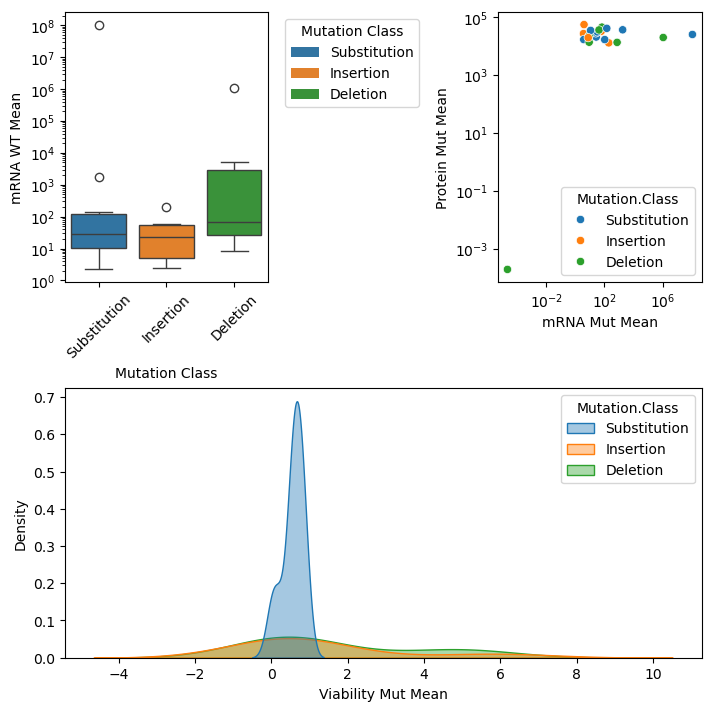

In [243]:
## three panel plot to support choice of 5 genes and mutations to prioritise

import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import seaborn as sbn
import pandas as pd


## build the plot data frame
plot_df = pd.DataFrame({
    "Gene":               combined_data["Gene"],
    "Mutation.Class":     mutation_df["mutation_type"],
    "mRNA.WT.Mean":       combined_data[["mRNA.Expression.WT.Rep1",
                                          "mRNA.Expression.WT.Rep2",
                                          "mRNA.Expression.WT.Rep3"]].mean(axis=1),
    "mRNA.Mut.Mean":      combined_data[["mRNA.Expression.Mut.Rep1",
                                          "mRNA.Expression.Mut.Rep2",
                                          "mRNA.Expression.Mut.Rep3"]].mean(axis=1),
    "Protein.Mut.Mean":   combined_data[["Protein.Expression.Mut.Rep1",
                                          "Protein.Expression.Mut.Rep2",
                                          "Protein.Expression.Mut.Rep3"]].mean(axis=1),
    "Viability.Mut.Mean": combined_data[["CellViability.Mut.Rep1",
                                          "CellViability.Mut.Rep2",
                                          "CellViability.Mut.Rep3"]].mean(axis=1)
})

## build the three panel plot
fig, ax = plt.subplot_mosaic([["box", "scatter"], ["hist", "hist"]],
                              figsize=(7, 7), layout="constrained")

## edit the upper left boxplot
sbn.boxplot(plot_df, x="Mutation.Class", y="mRNA.WT.Mean",
            hue="Mutation.Class", ax=ax["box"])
ax["box"].set_xlabel("Mutation Class")
ax["box"].set_ylabel("mRNA WT Mean")
ax["box"].tick_params(axis="x", rotation=45)
ax["box"].set_yscale("log")
mutation_classes = plot_df["Mutation.Class"].unique()
handles = [plt.matplotlib.patches.Patch(facecolor=patch.get_facecolor(), 
           label=label) for patch, label in zip(ax["box"].patches, mutation_classes)]
ax["box"].legend(handles=handles, title="Mutation Class", 
                 bbox_to_anchor=(1.05, 1), loc="upper left")

## edit the upper right scatterplot
sbn.scatterplot(plot_df, x="mRNA.Mut.Mean", y="Protein.Mut.Mean",
                hue="Mutation.Class", ax=ax["scatter"])
ax["scatter"].set_xlabel("mRNA Mut Mean")
ax["scatter"].set_ylabel("Protein Mut Mean")
ax["scatter"].set_xscale("log")
ax["scatter"].set_yscale("log")  

## edit the bottom histogram
sbn.kdeplot(plot_df, x="Viability.Mut.Mean",
            hue="Mutation.Class", ax=ax["hist"], fill=True, alpha=0.4)
ax["hist"].set_xlabel("Viability Mut Mean")
ax["hist"].set_ylabel("Density")

## display the plot
plt.show()

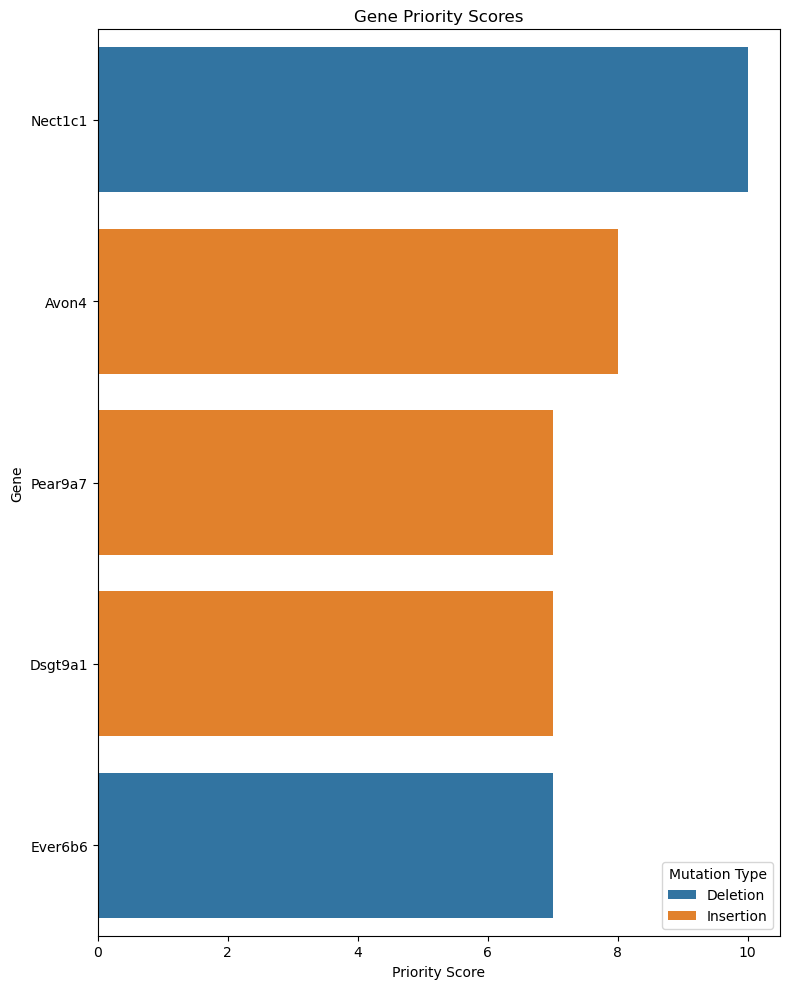

In [244]:
## bar chart that shows the top 5 genes chosen

## import the scores we determined earlier
scores_df = top5_df.sort_values("priority_score", ascending=True)

## create the plot
fig, ax = plt.subplots(figsize=(8, 10))
sbn.barplot(top5_df, x="priority_score", y="Gene",
            hue="mutation_type", ax=ax, orient="h")
ax.set_title("Gene Priority Scores")
ax.set_xlabel("Priority Score")
ax.set_ylabel("Gene")

## show which type of mutation each gene is
ax.legend(title="Mutation Type")
plt.tight_layout()

## display the plot
plt.show()

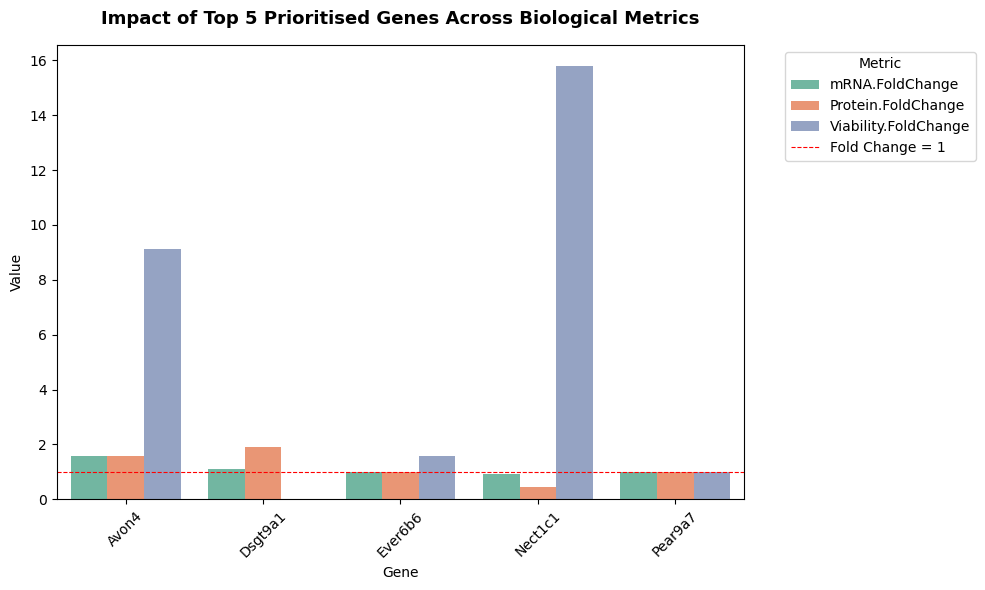

In [245]:
## build the data frame
top5_genes = top5_df["Gene"].tolist()

## determine if the gene is in the top five genes for analysis
mask = combined_data["Gene"].isin(top5_genes)
mrna_mask = mutation_df["Gene"].isin(top5_genes)
protein_mask = mutation_df["Gene"].isin(top5_genes)
viability_mask = mutation_df["Gene"].isin(top5_genes)

## bring is impact data for analysis
top5_impact = pd.DataFrame({
    "Gene":               combined_data[mask]["Gene"].values,
    "mRNA.FoldChange":    mrna_df[mrna_mask]["fold_change"].values,
    "Protein.FoldChange": protein_df[protein_mask]["fold_change"].values,
    "Viability.FoldChange": viability_df[viability_mask]["fold_change"].values
})

## melt data to long format
top5_melted = top5_impact.melt(id_vars="Gene",
                                value_vars=["mRNA.FoldChange",
                                            "Protein.FoldChange",
                                            "Viability.FoldChange"],
                                var_name="Metric",
                                value_name="Value")

## create bar chart
fig, ax = plt.subplots(figsize=(10, 6))
sbn.barplot(top5_melted, x="Gene", y="Value", hue="Metric",
            ax=ax, palette="Set2")

ax.set_title("Impact of Top 5 Prioritised Genes Across Biological Metrics",
             fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Gene")
ax.set_ylabel("Value")
ax.axhline(y=1, color="red", linestyle="--", 
           linewidth=0.8, label="Fold Change = 1")
ax.legend(title="Metric", bbox_to_anchor=(1.05, 1), loc="upper left")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()